In [1]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             roc_auc_score, roc_curve, PrecisionRecallDisplay)
from sklearn.datasets import load_breast_cancer

from xgboost import XGBClassifier

In [2]:
#LOADING THE DATA IN

data = load_breast_cancer()

#dataframe easier to read
data_frame = pd.DataFrame(data.data, columns = data.feature_names)
#1 = benign, 0 = malignant
data_frame['target'] = data.target

print(f"dataset shape: {data_frame.shape}")
data_frame.head() #outputting polished table,e asier to read

dataset shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
#PREPROCESSING

#features (x)
x = data_frame.drop('target', axis = 1)
#labels (y)
y = data_frame['target']

#splitting into 80% training and 20% for testing
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42) #need to check random state documentation

#setting mean to 0 and variance to 1 (standardization)
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

In [4]:
#INITIALIZING MODEL

model = XGBClassifier(
    learning_rate = 0.1,
    max_depth = 3,
    n_estimators = 100,
    eval_metric = 'logloss'
)

In [5]:
#TRAINING MODEL

#training
model.fit(x_train, y_train)

#debugging
print("training complete")

training complete


In [6]:
#EVALUATION

preds = model.predict(x_test)
proba = model.predict_proba(x_test)[:, 1]

print(f"Model accuracy: {accuracy_score(y_test, preds):.4f}")
print(f"ROC-AUC:        {roc_auc_score(y_test, proba):.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, preds))

print("\nClassification report:")
print(classification_report(y_test, preds, target_names=['malignant', 'benign']))

#cross-validation
cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')
print(f"\nCross-validation accuracy (5-fold):")
print(f"  Mean:  {cv_scores.mean():.4f}")
print(f"  Std:   {cv_scores.std():.4f}")
print(f"  Min:   {cv_scores.min():.4f}")
print(f"  Max:   {cv_scores.max():.4f}")

Model accuracy: 0.9561
ROC-AUC:        0.9931

Confusion matrix:
[[40  3]
 [ 2 69]]

Classification report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Cross-validation accuracy (5-fold):
  Mean:  0.9648
  Std:   0.0146
  Min:   0.9451
  Max:   0.9890


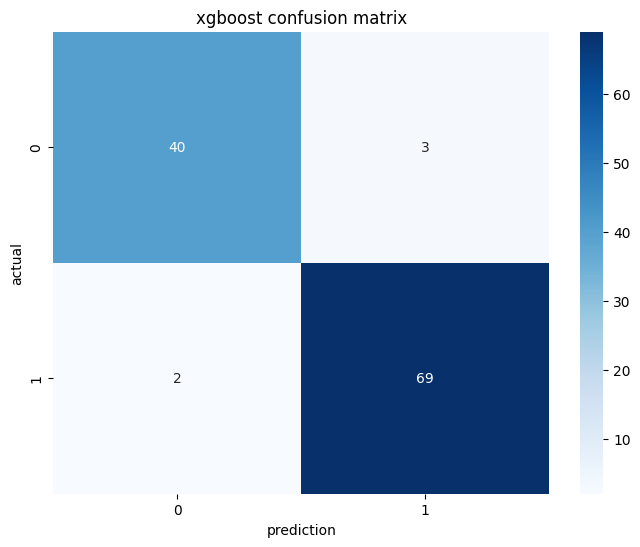

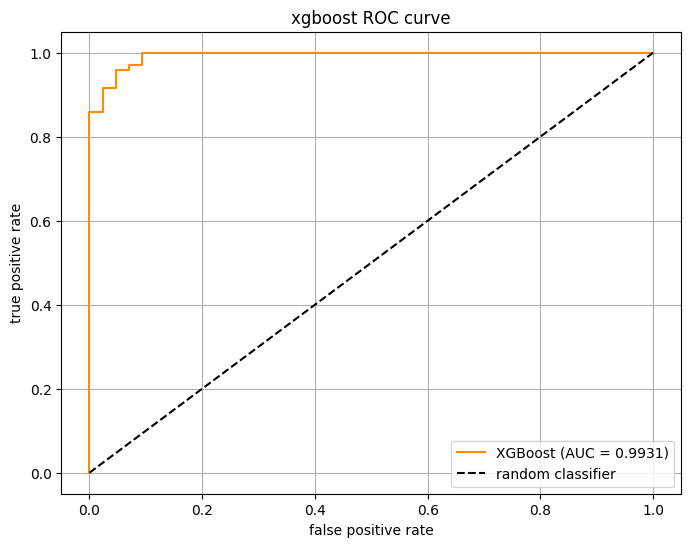

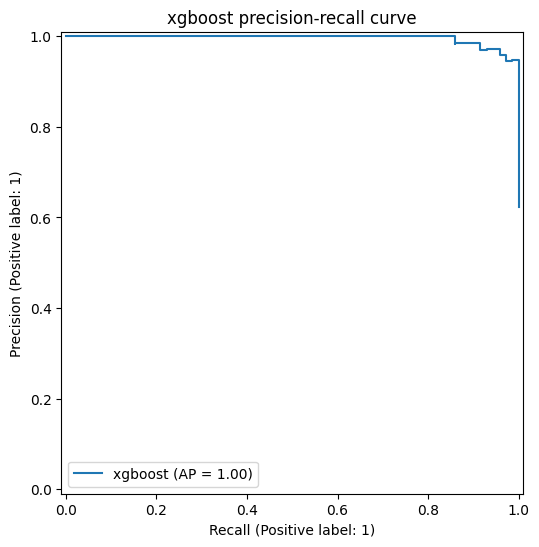

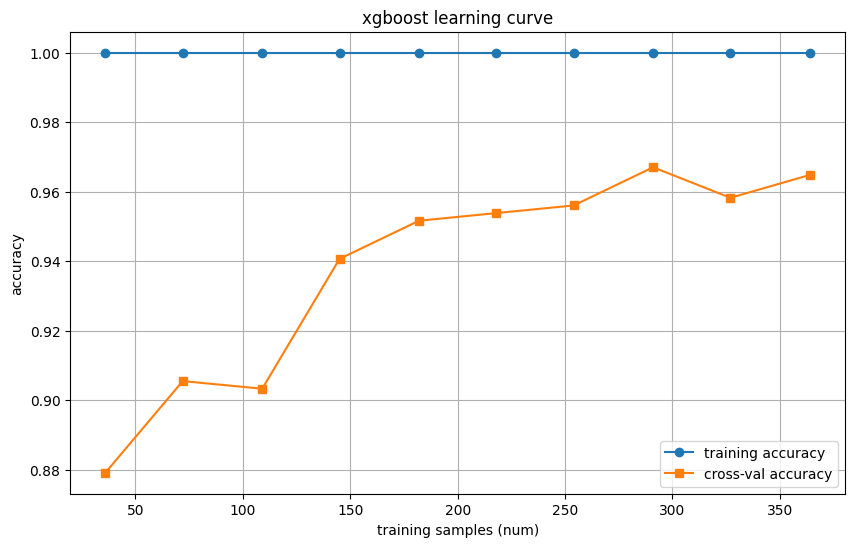

In [7]:
#VISUALIZATION

if not os.path.exists('figures'):
    os.makedirs('figures')

#confusion matrix
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel("prediction")
ax.set_ylabel("actual")
ax.set_title("xgboost confusion matrix")
fig.savefig('figures/xgboost_confusion_matrix.png')
plt.show()

#ROC curve
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

fig5, ax5 = plt.subplots(figsize=(8,6))
ax5.plot(fpr, tpr, label=f'XGBoost (AUC = {auc:.4f})', color='darkorange')
ax5.plot([0,1], [0,1], 'k--', label='random classifier')
ax5.set_xlabel("false positive rate")
ax5.set_ylabel("true positive rate")
ax5.set_title("xgboost ROC curve")
ax5.legend()
ax5.grid(True)
fig5.savefig('figures/xgboost_roc_curve.png')
plt.show()

#precision recall curve
fig3, ax3 = plt.subplots(figsize=(8,6))
disp = PrecisionRecallDisplay.from_estimator(model, x_test, y_test, name="xgboost", ax=ax3)
ax3.set_title("xgboost precision-recall curve")
fig3.savefig('figures/xgboost_precision_recall_curve.png')
plt.show()

#learning curve
train_size, train_score, test_score = learning_curve(model, x_train, y_train, cv=5, scoring='accuracy', train_sizes=np.linspace(.10, 1.0, 10))

train_m = np.mean(train_score, axis=1)
test_m = np.mean(test_score, axis=1)

fig2, ax2 = plt.subplots(figsize=(10,6))
ax2.plot(train_size, train_m, label='training accuracy', marker='o')
ax2.plot(train_size, test_m, label='cross-val accuracy', marker='s')
ax2.set_xlabel("training samples (num)")
ax2.set_ylabel("accuracy")
ax2.set_title("xgboost learning curve")
ax2.grid(True)
ax2.legend()
fig2.savefig('figures/xgboost_learning_curve.png')
plt.show()

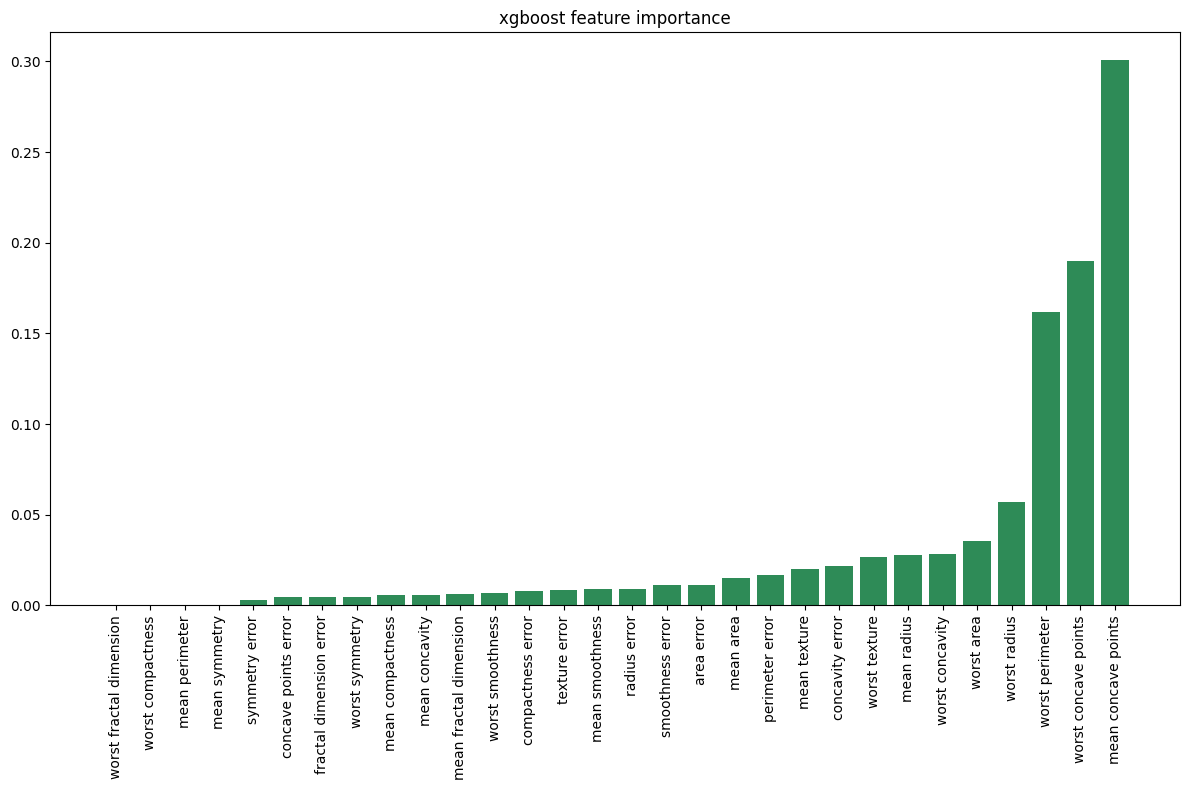

In [8]:
#FEATURE IMPORTANCE

imp = model.feature_importances_
ind = np.argsort(imp)

fig4, ax4 = plt.subplots(figsize=(12,8))
ax4.set_title("xgboost feature importance")
ax4.bar(range(x.shape[1]), imp[ind], align="center", color="seagreen")
ax4.set_xticks(range(x.shape[1]))
ax4.set_xticklabels([data.feature_names[i] for i in ind], rotation=90)
fig4.tight_layout()

fig4.savefig('figures/xgboost_feature_importance.png')
plt.show()
